# Create design matrix
- Map response as a regressor
- Then split it up based on valence and volatility
- See how they are correlated amongst each other

In [1]:
import utils

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import math
import os
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix, plot_design_matrix_correlation

#from analyses_behavioural.modelling.martin_modelling.plots import subjectively_correct

plt.rcParams.update(plt.rcParamsDefault)
pd.set_option('display.max_columns', None)

In [2]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','design_matrices')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# To load the trigger files
def find_trigger_file(pattern: str, folder: str = '.') -> pd.DataFrame:
    folder = Path(folder)
    matches = list(folder.glob(pattern))

    if len(matches) == 0:
        raise FileNotFoundError(f"No files matching '{pattern}' in {folder}")
    if len(matches) > 1:
        raise ValueError(f"Multiple files match '{pattern}': {matches}")

    return pd.read_csv(matches[0], delimiter=';')

In [4]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/'
unique_subject_ids = [52, 53, 54, 55, 57]
unique_sessions = [2, 3, 4]

# Now create a boxcar for every single trial
boxcar_duration = 1.7
# Define the maximum displacement for volumes that are excluded [mm]
framewise_displacement_limit = 2
# Filter out objectively incorrect trials
filter_out_incorrect_trials = True

# Load and combine the datasets
combined_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, fmri_analysis=True)

print(combined_dataframe)

     subject_id     session  previous_outcome subjectively_correct  stay
0       sub-052  session-02              <NA>                 Late  <NA>
1       sub-052  session-02              <NA>                False  <NA>
2       sub-052  session-02              <NA>                 True  <NA>
3       sub-052  session-02              <NA>                 True  <NA>
4       sub-052  session-02              <NA>                False     1
...         ...         ...               ...                  ...   ...
6775    sub-057  session-04              <NA>                 True  <NA>
6776    sub-057  session-04                 1                 True     1
6777    sub-057  session-04                 1                 True     1
6778    sub-057  session-04                 1                 True     1
6779    sub-057  session-04                 1                False  <NA>

[6780 rows x 5 columns]
      trial  emotional_cue_time  response objectively_correct  \
0         0        1.769530e+09   

/Volumes/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:757: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  removed_trials['removed_trial'] = 'removed_trial'


Creating event file for subject 52 and session 2
32
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.147119   1.369851
5                              removed_trial     9.591200   0.844241
8                              removed_trial    14.259931   0.784553
11                             removed_trial    18.562464   0.690180
14                             removed_trial    23.018315   0.717532
17                             removed_trial    26.956866   0.603045
20                             removed_trial    31.539459   0.720134
23                             removed_trial    34.923889   0.626518
24       happy-most_rewarding_avoid-volatile    38.511245   0.647203
25          happy-executed_approach-volatile    38.511245   0.647203
27       happy-most_rewarding_avoid-volatile    42.248241   0.721384
28          happy-executed_approach-volatile    42.248241   0.

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


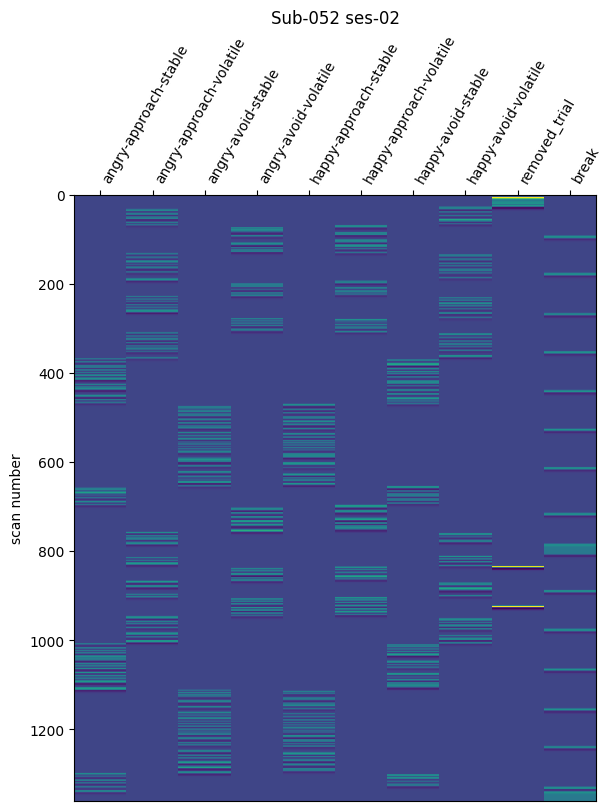

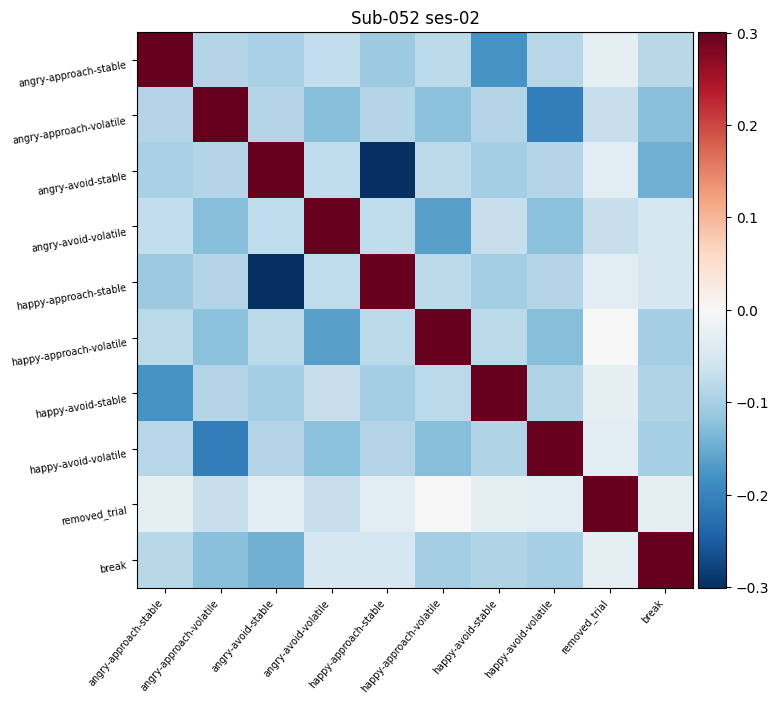

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.36737692872887584% of volumes have been removed.

Creating event file for subject 52 and session 3
30
60
90
120
152
180
210
240
270
300
330
366
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.045866   1.374031
5                              removed_trial     9.480143   0.782549
8                              removed_trial    14.149288   0.604659
11                             removed_trial    18.455688   0.664597
14                             removed_trial    22.908866   0.677657
17                             removed_trial    26.846686

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


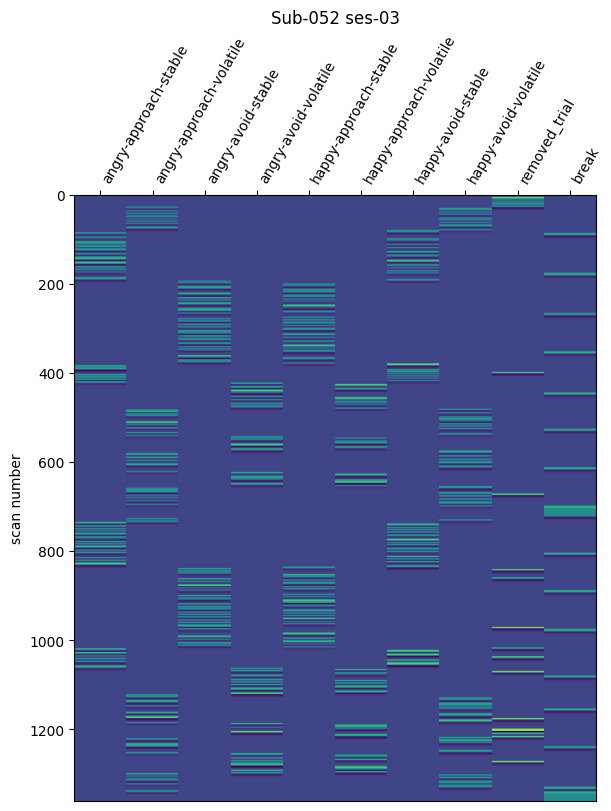

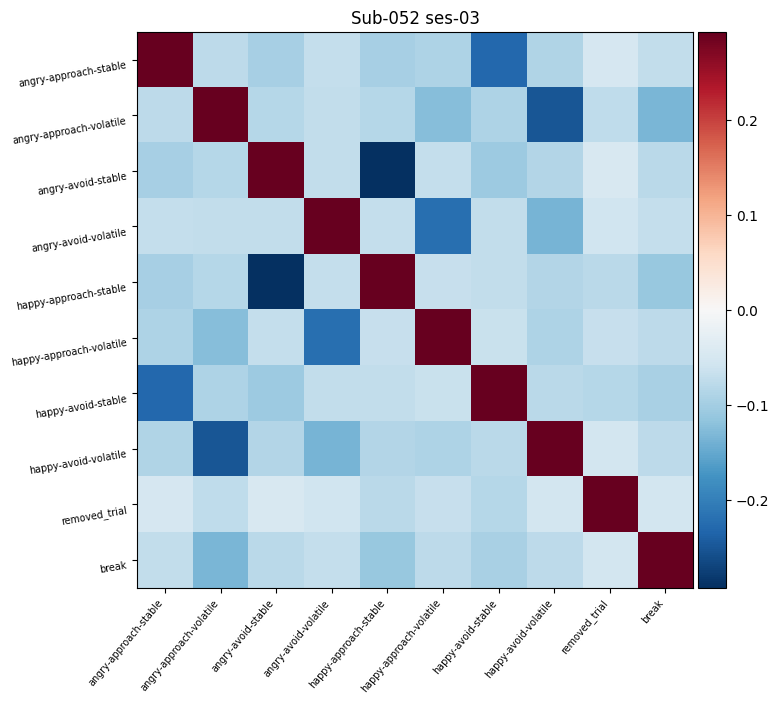

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.2939015429831006% of volumes have been removed.

Creating event file for subject 52 and session 4
30
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.059612   0.883737
5                              removed_trial     9.491522   0.609971
8                              removed_trial    14.168633   0.652487
11                             removed_trial    18.475568   0.593600
14                             removed_trial    22.935780   0.693580
17                             removed_trial    26.871115 

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


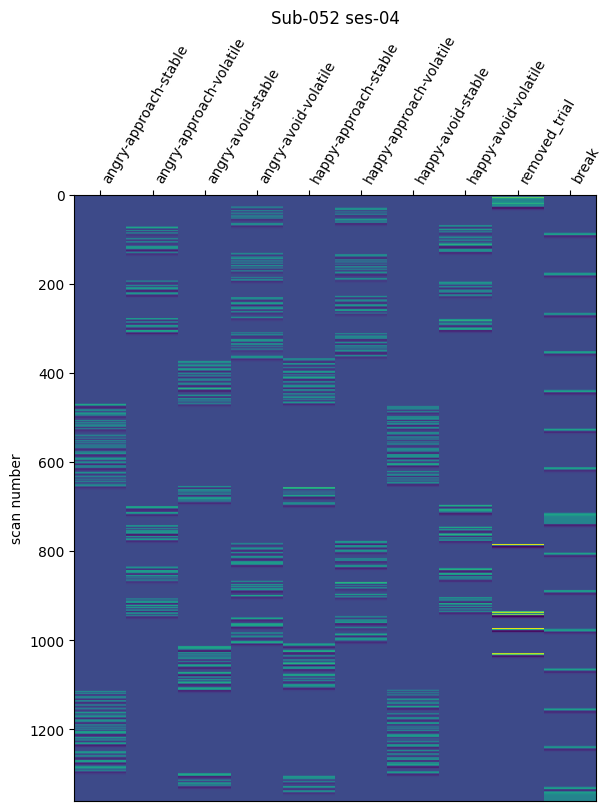

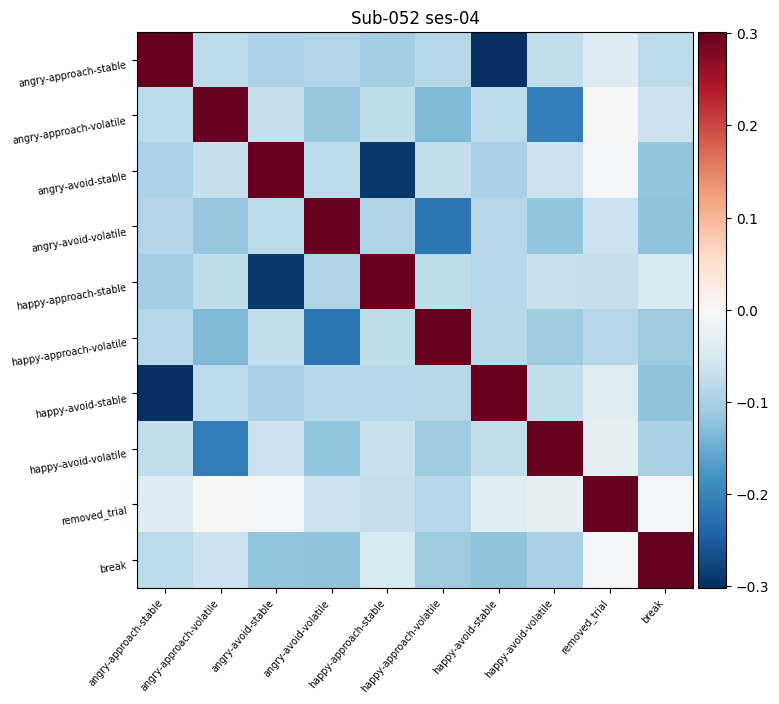

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.0% of volumes have been removed.

Creating event file for subject 53 and session 2
32
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.137678   1.067293
5                              removed_trial     9.562333   1.276718
8                              removed_trial    14.241365   1.300568
11                             removed_trial    18.547259   1.015151
14                             removed_trial    23.005099   1.009426
17                             removed_trial    26.943796   0.855050
20  

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


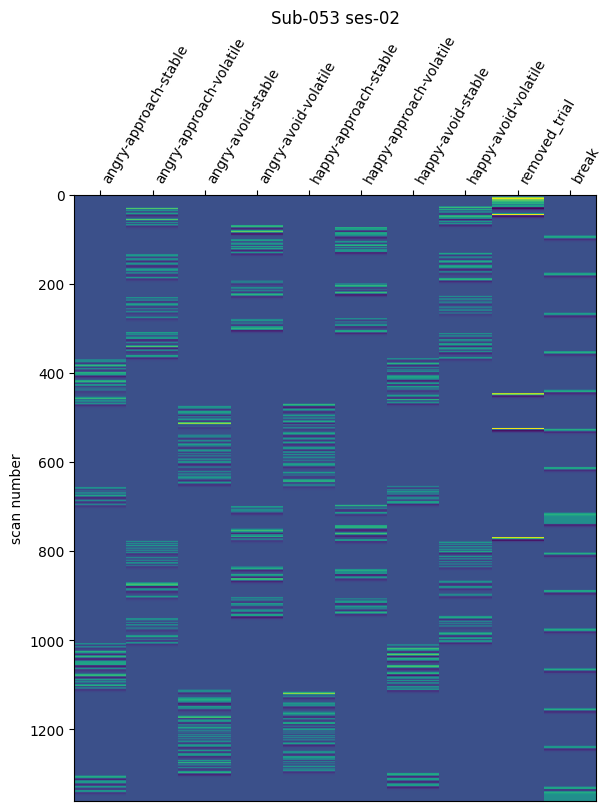

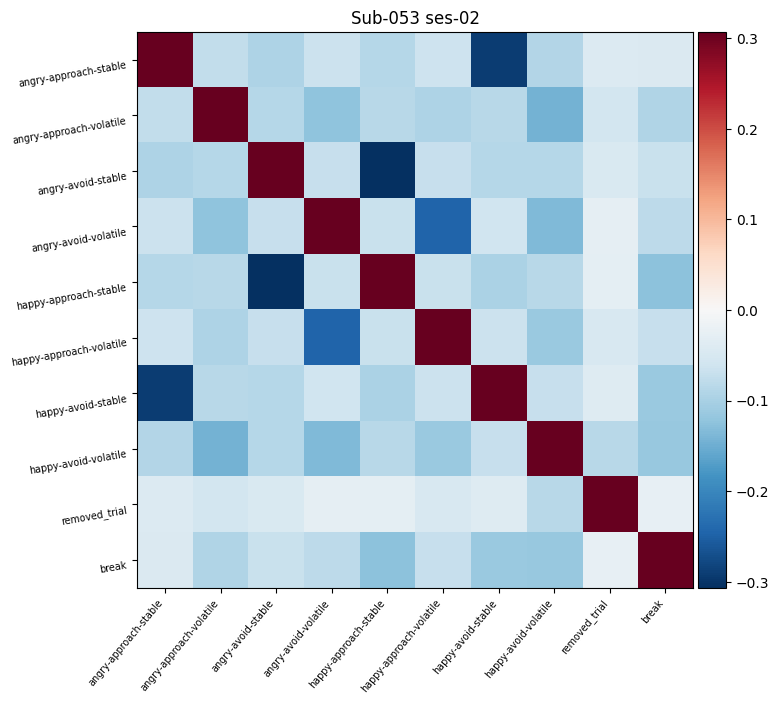

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.07347538574577515% of volumes have been removed.

Creating event file for subject 53 and session 3
30
60
90
120
150
180
210
240
270
300
330
366
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.081982   1.003438
5                              removed_trial     9.515166   0.738340
8                              removed_trial    14.185926   0.742190
11                             removed_trial    18.489036   0.612171
14                             removed_trial    22.941763   0.894897
17                             removed_trial    26.869963

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


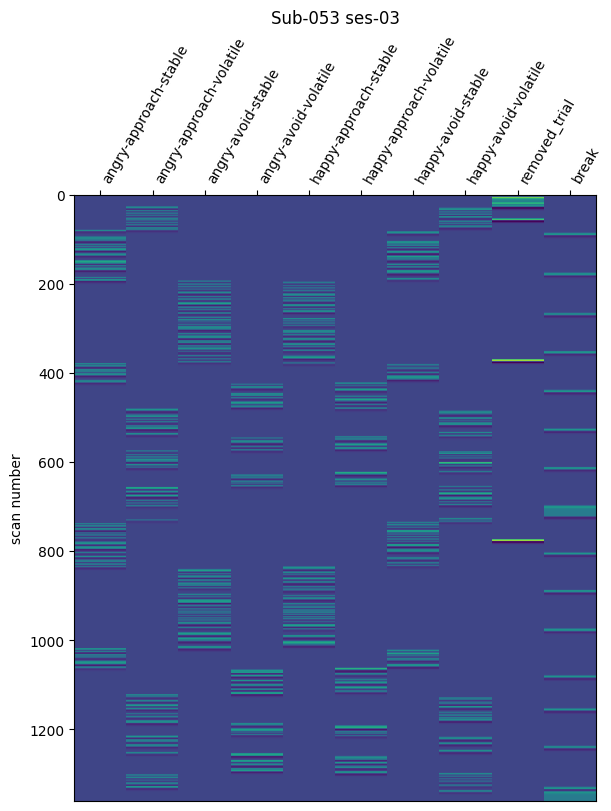

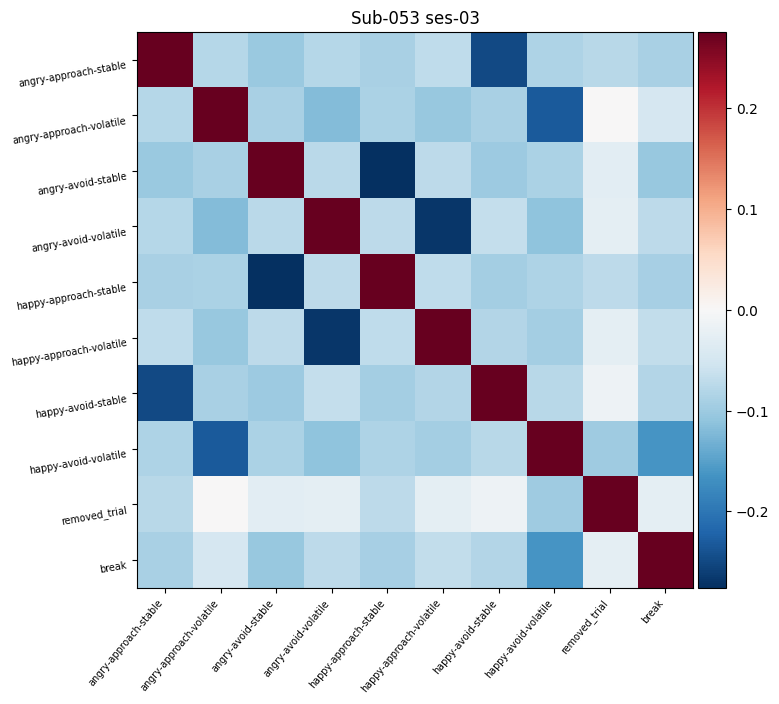

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.2204261572373255% of volumes have been removed.

Creating event file for subject 53 and session 4
30
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.092943   1.153451
5                              removed_trial     9.525413   0.693582
8                              removed_trial    14.200263   0.702661
11                             removed_trial    18.496169   0.664021
14                             removed_trial    22.951386   0.797753
17                             removed_trial    26.881467 

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


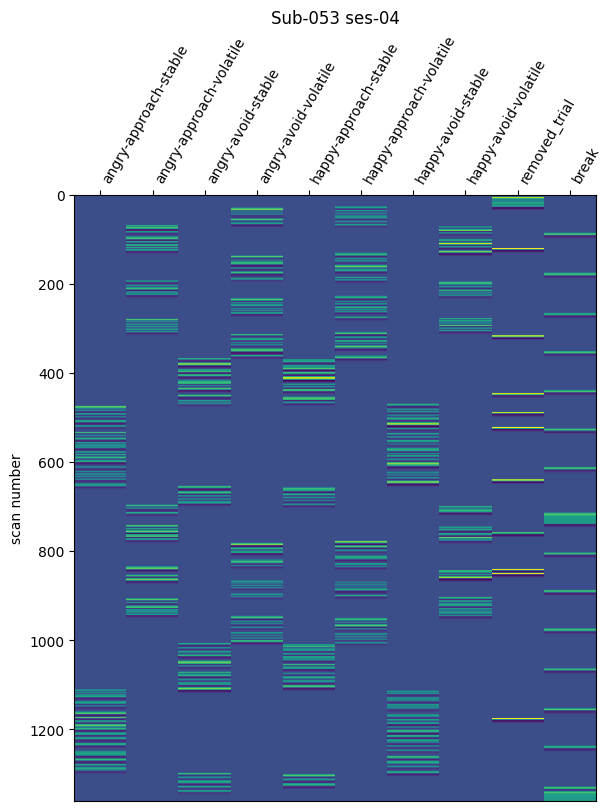

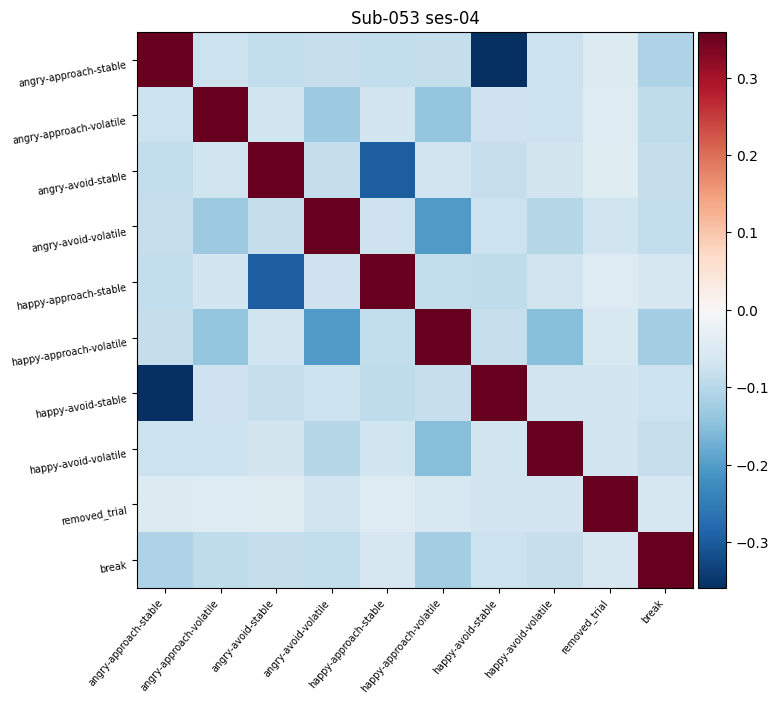

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.07347538574577515% of volumes have been removed.

Creating event file for subject 54 and session 2
30
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.174525   1.274669
5                              removed_trial     9.605132   0.743697
8                              removed_trial    14.280888   0.818875
11                             removed_trial    18.578881   0.527604
14                             removed_trial    23.036855   0.781560
17                             removed_trial    26.977753

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


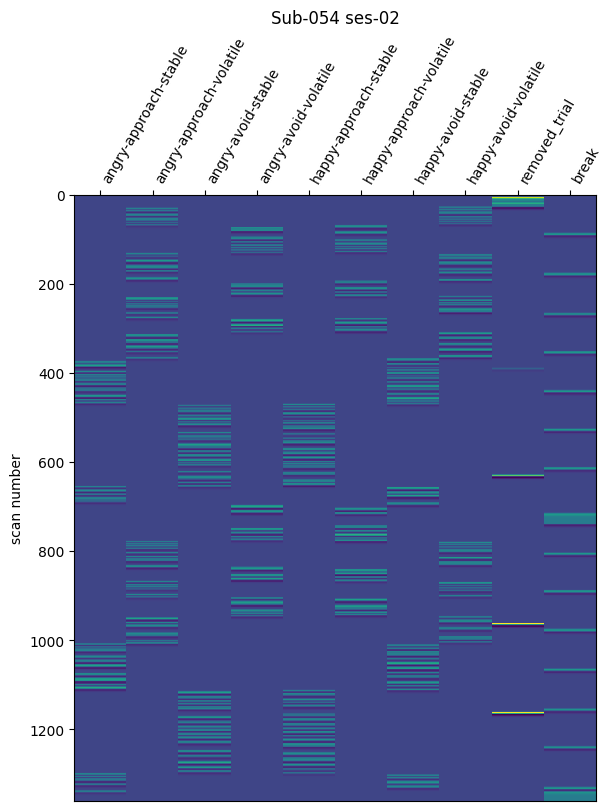

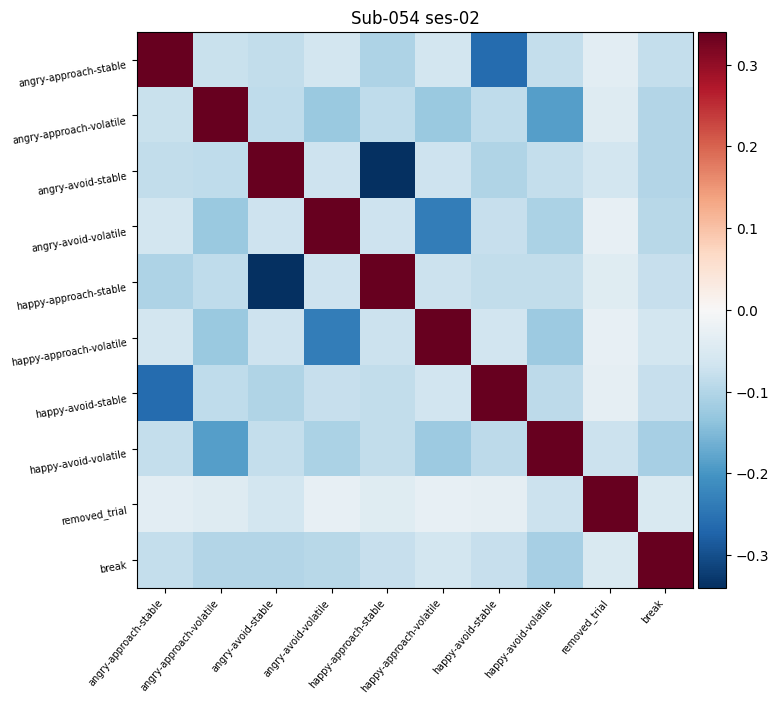

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.07347538574577515% of volumes have been removed.

Creating event file for subject 54 and session 3
30
60
90
120
150
180
210
240
270
300
330
366
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.046603   0.750861
5                              removed_trial     9.475564   0.612867
8                              removed_trial    14.152227   0.678354
11                             removed_trial    18.447867   0.523602
14                             removed_trial    22.902789   0.794846
17                             removed_trial    26.839884

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


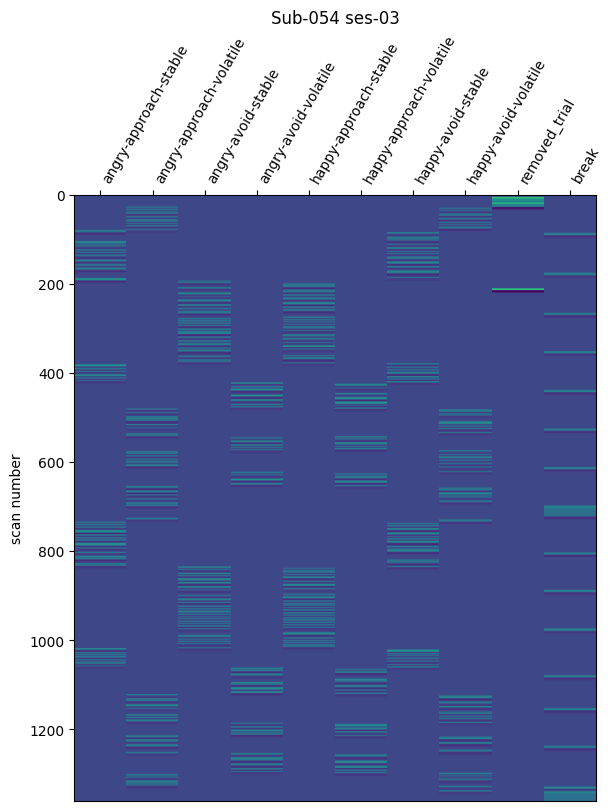

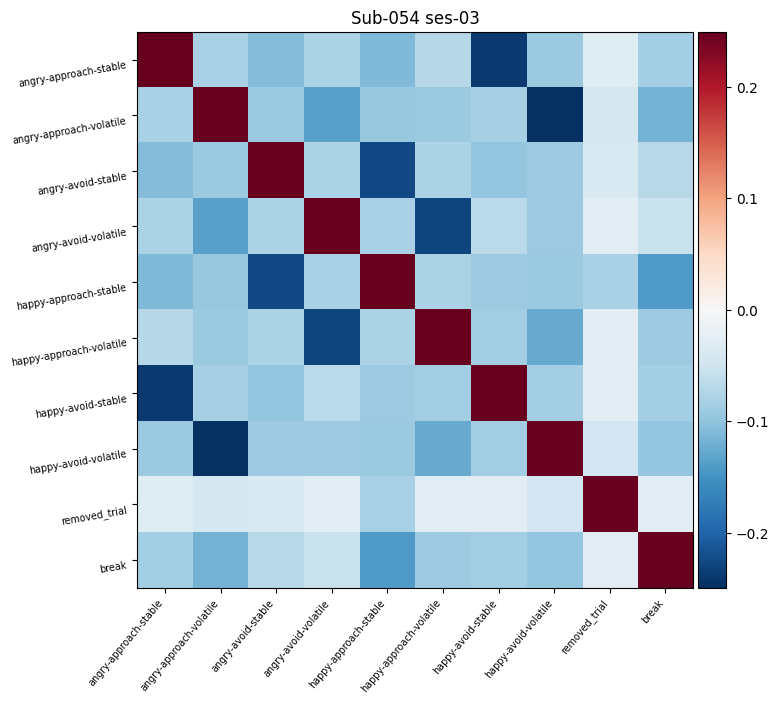

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.0% of volumes have been removed.

Creating event file for subject 54 and session 4
30
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.138703   0.560441
5                              removed_trial     9.591975   0.634785
8                              removed_trial    14.272972   0.669937
11                             removed_trial    18.605719   0.668539
14                             removed_trial    23.063489   0.480021
17                             removed_trial    27.032338   0.627357
20  

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


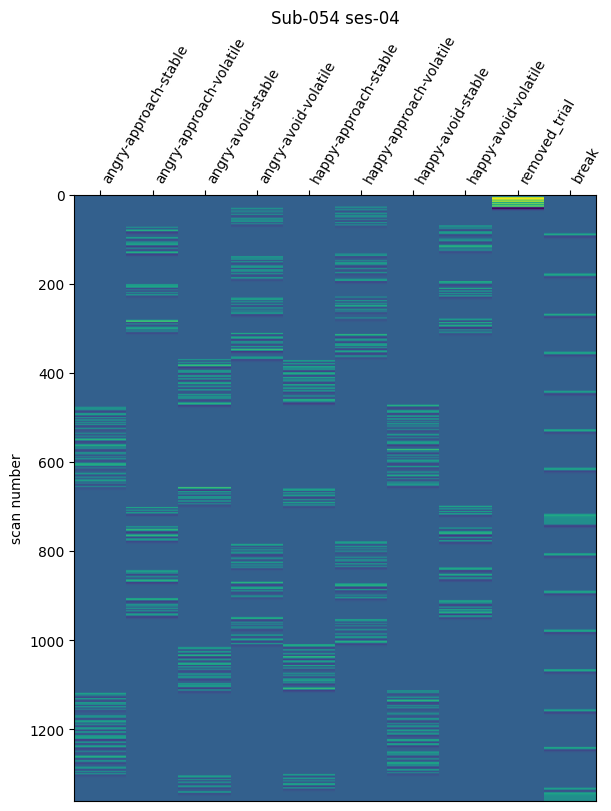

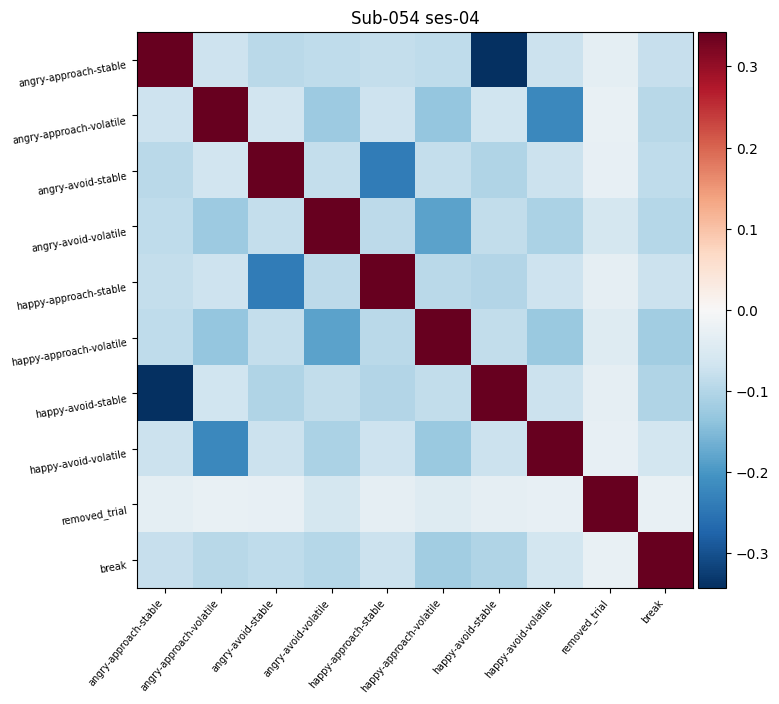

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.2939015429831006% of volumes have been removed.

Creating event file for subject 55 and session 2
32
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.045609   0.911121
5                              removed_trial     9.481693   0.540970
8                              removed_trial    14.158123   0.706583
11                             removed_trial    18.463125   0.543727
14                             removed_trial    22.914082   0.627529
17                             removed_trial    26.850281 

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


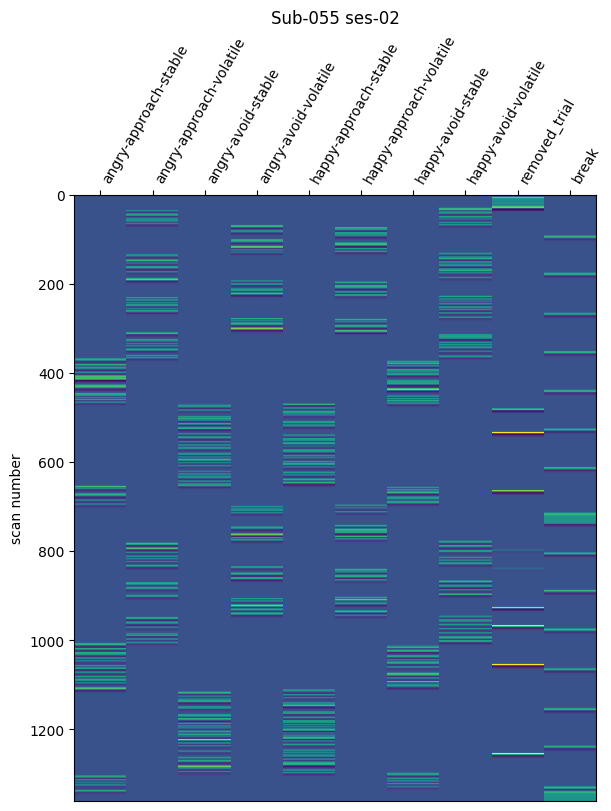

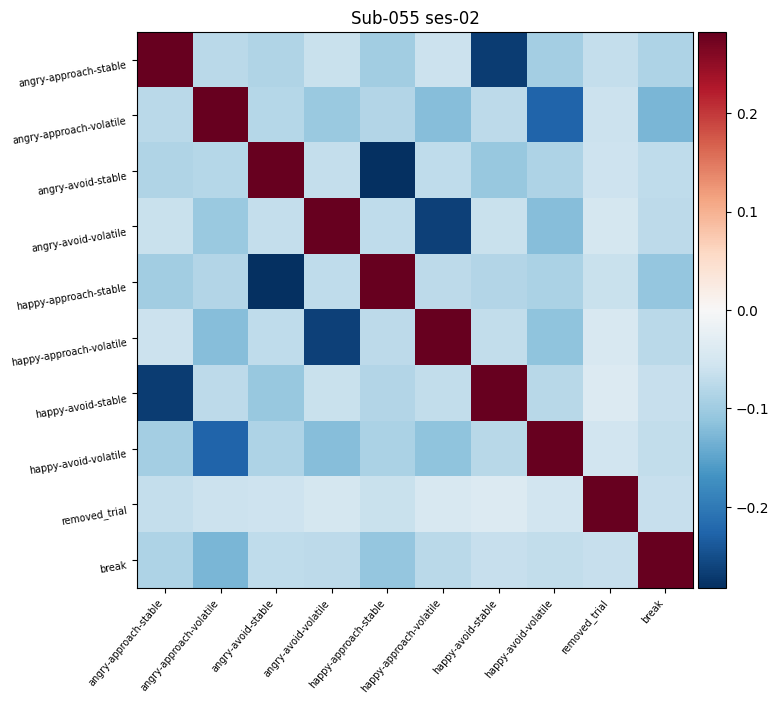

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.0% of volumes have been removed.

Creating event file for subject 55 and session 3
30
60
90
120
150
180
210
240
270
300
330
366
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.108126   0.720110
5                              removed_trial     9.542581   0.802588
8                              removed_trial    14.219462   0.548566
11                             removed_trial    18.526393   0.543087
14                             removed_trial    22.980095   0.556572
17                             removed_trial    26.912294   0.567083
20  

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


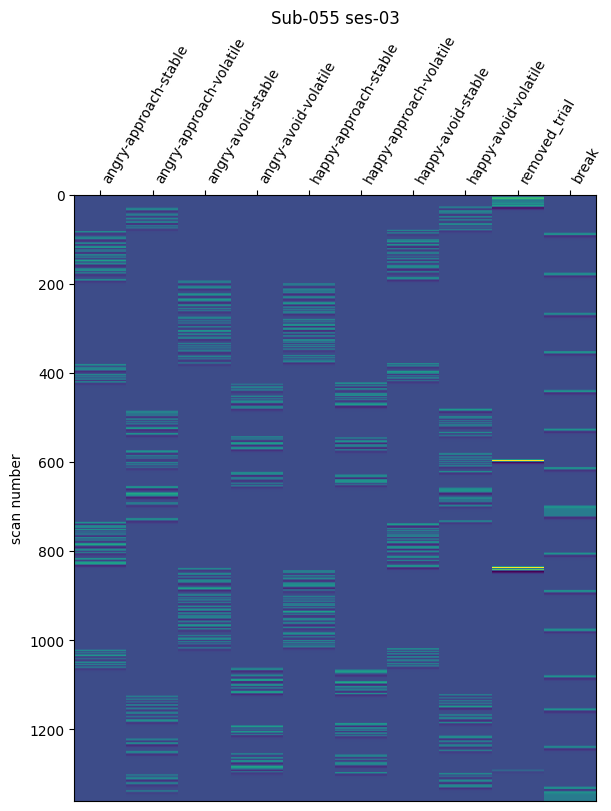

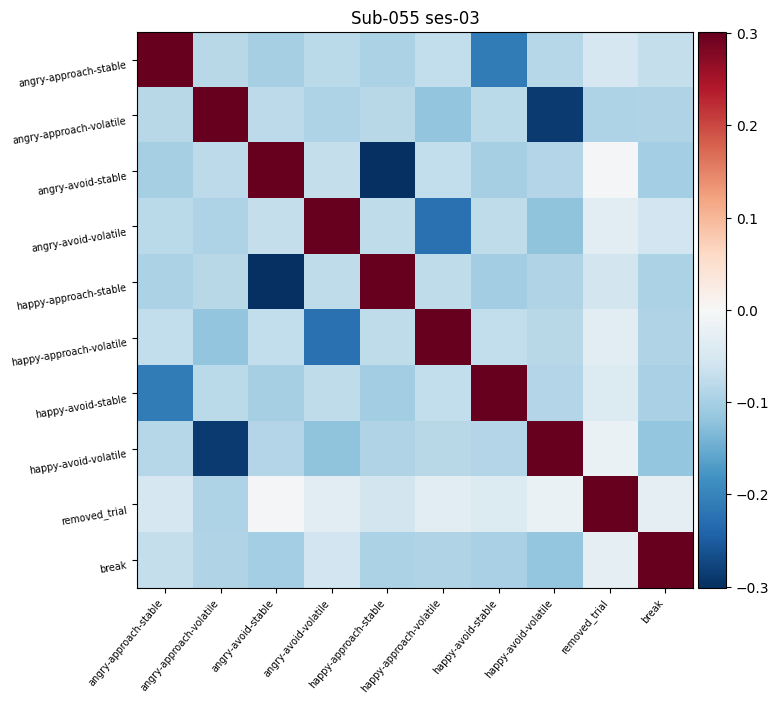

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.0% of volumes have been removed.

Creating event file for subject 55 and session 4
30
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.047973   0.667440
5                              removed_trial     9.483789   0.673646
8                              removed_trial    14.156913   0.635576
11                             removed_trial    18.460532   0.606227
14                             removed_trial    22.915087   0.643178
17                             removed_trial    26.867923   0.605106
20  

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


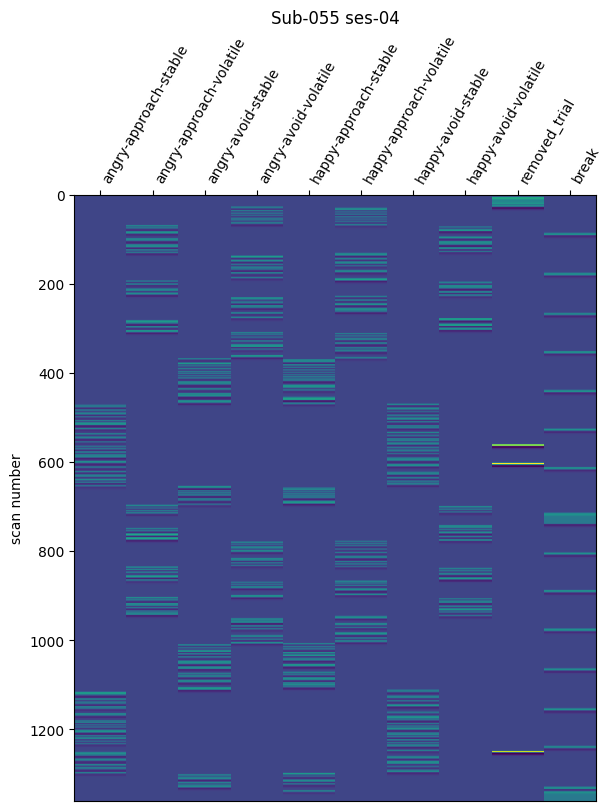

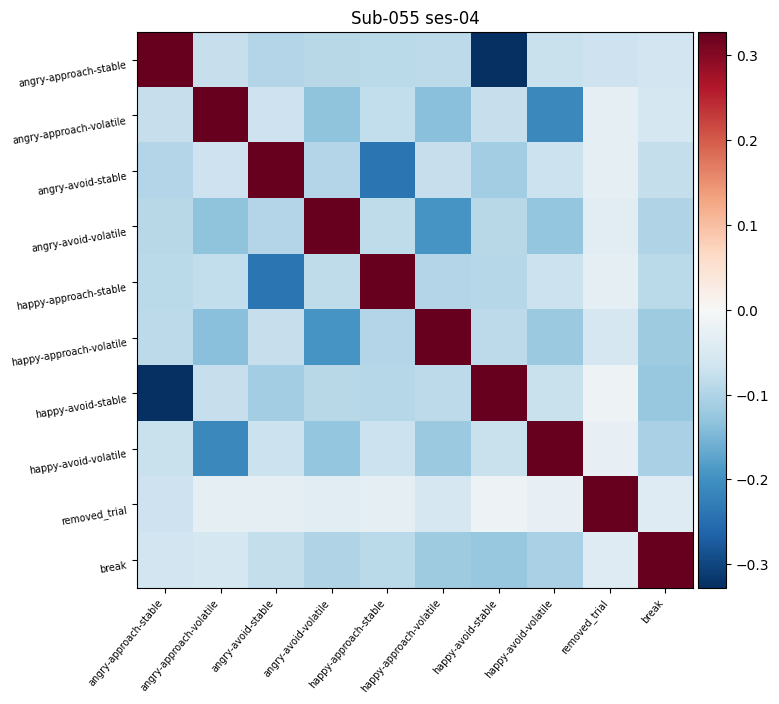

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.0% of volumes have been removed.

Creating event file for subject 57 and session 2
30
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.043884   1.208809
5                              removed_trial     9.469791   0.716683
8                              removed_trial    14.150550   0.794216
11                             removed_trial    18.451921   1.243194
14                             removed_trial    22.900733   1.018408
17                             removed_trial    26.830611   0.956878
20  

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


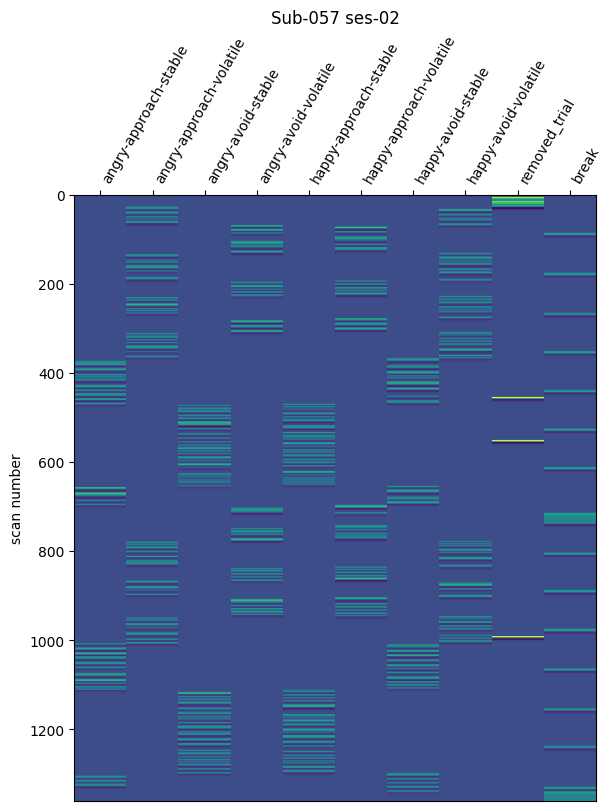

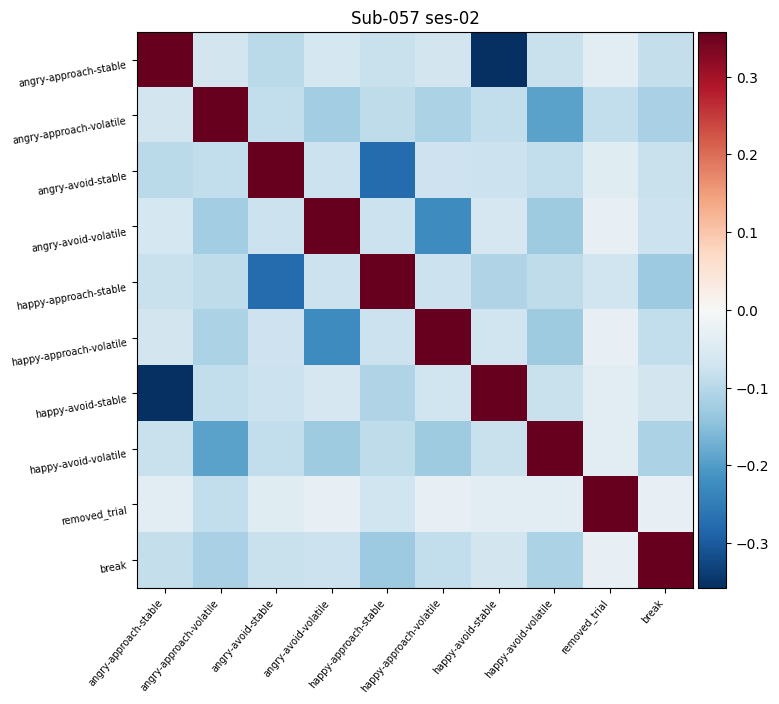

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.0% of volumes have been removed.

Creating event file for subject 57 and session 3
30
60
90
120
152
180
210
240
270
300
330
366
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.045978   1.010743
5                              removed_trial     9.477724   0.585837
8                              removed_trial    14.148494   0.667074
11                             removed_trial    18.452003   0.813630
14                             removed_trial    22.911166   0.689175
17                             removed_trial    26.842607   0.829459
20  

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


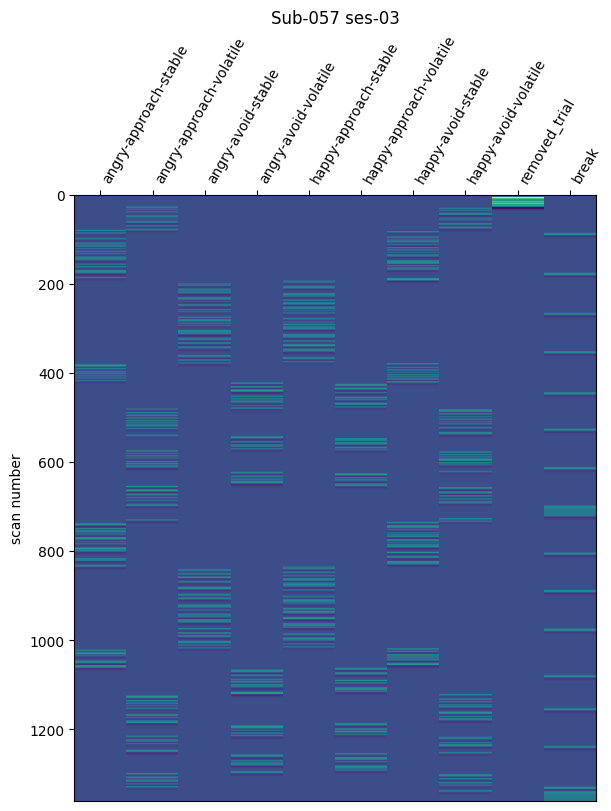

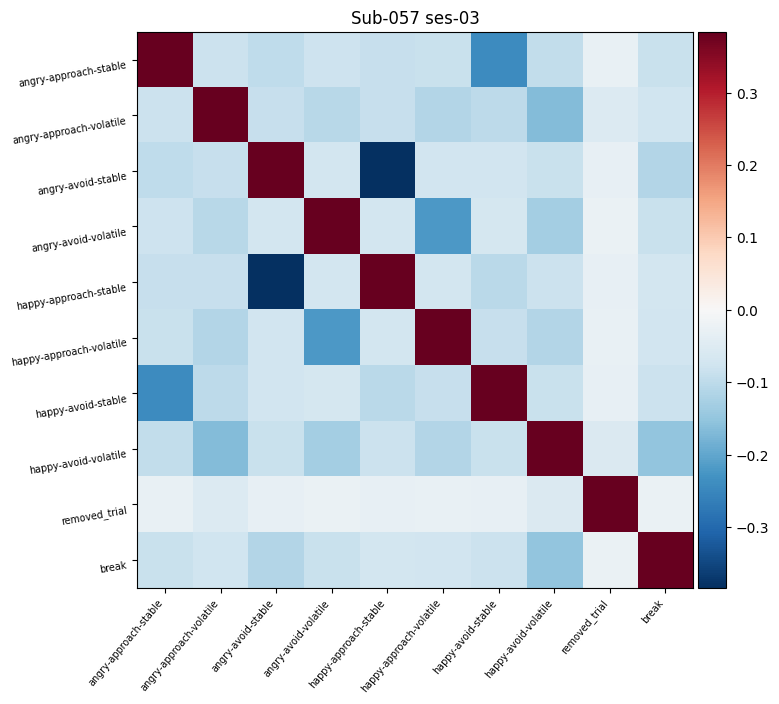

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.07347538574577515% of volumes have been removed.

Creating event file for subject 57 and session 4
30
60
90
120
150
180
210
246
270
300
330
360
390
420
450
451
                                  trial_type        onset   duration
2                              removed_trial     5.077368   0.923308
5                              removed_trial     9.505739   0.868719
8                              removed_trial    14.187267   0.886375
11                             removed_trial    18.483895   0.783524
14                             removed_trial    22.937261   0.811553
17                             removed_trial    26.873228

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8655/3316680314.py:116: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


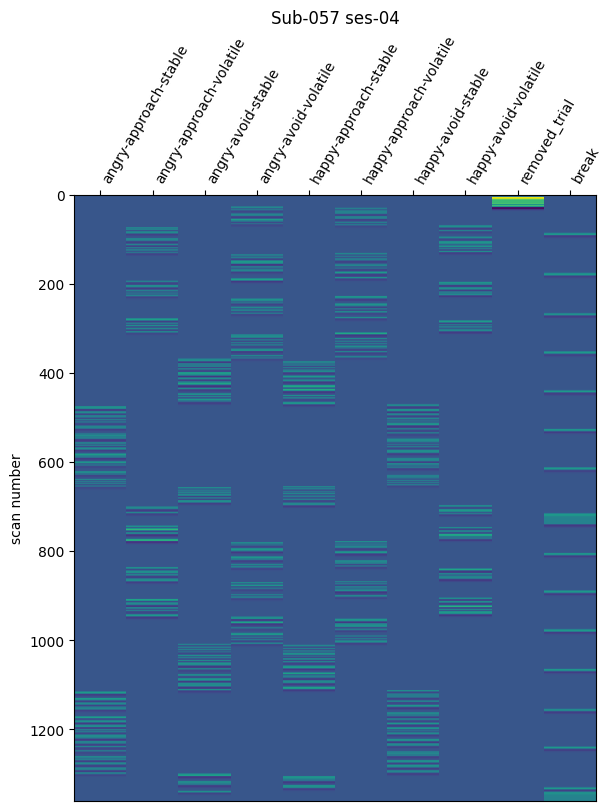

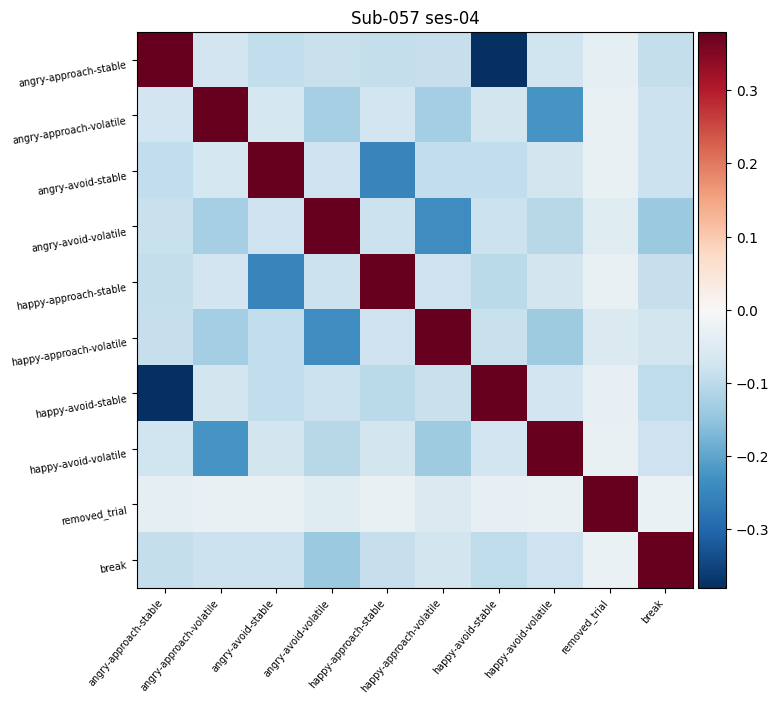

confound title: a_comp_cor
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'a_comp_cor_05']
0.0% of volumes have been removed.



In [5]:
pd.set_option('display.max_rows', None)
feedback_duration = 0.1
# Repetition time
tr = 1.5

for subject_id in unique_subject_ids:
    for session in unique_sessions:
        # Set subject raw folder for later use:
        project_folder = '/Volumes/project/3025011.02'
        subject_raw_folder = f'{project_folder}/raw/sub-{subject_id:03}/ses-mri{session:02}'
        subject_func_folder = f'{project_folder}/bids/sub-{subject_id:03}/ses-mri{session:02}/func'
        fsl_folder = f'{project_folder}/bids/derivatives/fsl/sub-{subject_id:03}/ses-mri{session:02}/func'
        confounds_file = f'{project_folder}/bids/derivatives/fmriprep/sub-{subject_id:03}/ses-mri{session:02}/func/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_desc-confounds_timeseries.tsv'
        os.makedirs(fsl_folder, exist_ok=True)

        # If participant does not have subject data yet
        if not os.path.exists(confounds_file):
            print(f'fMRIprep has not yet been run for subject {subject_id} and session {session}')
            continue
        else:
            print(f'Creating event file for subject {subject_id} and session {session}')

        # Add subject and session columns
        dataframe = combined_dataframe[combined_dataframe['subject_id'] == f'sub-{subject_id:03}']
        dataframe = dataframe[dataframe['session'] == f'session-{session:02}']
        dataframe = dataframe.reset_index(drop=True)

        # Create version of comments that only contain responses, cues and feedback
        dataframe['contains_response'] = np.where(dataframe['response'].notna(), 'response', '')
        dataframe['contains_cue'] = np.where(dataframe['valence'].notna(), 'cue', '')
        feedback_binary = [
            dataframe['subjectively_correct'].isin([True, 'True']),
            dataframe['subjectively_correct'].isin([False, 'False']),
        ]
        feedback_strings = ['subjectively_correct', 'subjectively_incorrect']
        dataframe['contains_feedback'] = np.select(feedback_binary, feedback_strings, default='')

        # Combine variables
        dataframe['most_rewarding_response'] = dataframe['most_rewarding_response'].replace({'approach': 'most_rewarding_approach', 'avoid': 'most_rewarding_avoid'})
        dataframe['executed_response'] = dataframe['response'].replace({'approach': 'executed_approach', 'avoid': 'executed_avoid'})
        dataframe['cue-valence-instructed_response-volatility'] = dataframe['valence'] + '-' + dataframe['most_rewarding_response'] + '-' + dataframe['volatility']
        dataframe['cue-valence-executed_response-volatility'] = dataframe['valence'] + '-' + dataframe['executed_response'] + '-' + dataframe['volatility']

        # Determine when the scan for the first volume starts
        trigger_signals = find_trigger_file(f'trigger_signals_sub-{subject_id:03}_session-{session:02}*.csv', f'{subject_raw_folder}/beh')
        first_volume_start = trigger_signals.loc[trigger_signals['trigger'] == 1, 'trigger_time'].item()
        last_volume_start = trigger_signals.loc[trigger_signals['trigger'] == 1361, 'trigger_time'].item()
        # Note down when each trial and each response starts
        last_volume_start = last_volume_start - first_volume_start
        dataframe['emotional_cue_time'] = dataframe['emotional_cue_time'] - first_volume_start
        dataframe['response_time'] = dataframe['response_time'] - first_volume_start
        dataframe['feedback_time'] = dataframe['feedback_time'] - first_volume_start

        # Create a boxcar
        dataframe['onset'] = dataframe['emotional_cue_time']
        #dataframe['duration'] = boxcar_duration
        dataframe['duration'] = dataframe['feedback_time'] - dataframe['onset'] + feedback_duration # time that the visual feedback is shown

        # Add a regressor for breaks
        dataframe['break'] = np.where(dataframe['trial_duration'] > 10, 'break', 'no_break')
        if dataframe['trial'].max() == 451:
            dataframe.loc[451, 'break'] = 'break'
        else:
            print('Trials are missing')

        # Restructure into a time-series
        restructured_rows = []
        for _, row in dataframe.iterrows():
            restructured_rows.append({'trial_type': row['cue-valence-instructed_response-volatility'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['cue-valence-executed_response-volatility'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['removed_trial'], 'onset': row['onset'], 'duration': row['duration']})
            if row['break'] == 'break':
                print(row['trial'])
                if row['trial'] == 451:
                    break_start = row['feedback_time'] + feedback_duration
                    break_duration = last_volume_start - break_start + tr
                else:
                    break_start = row['feedback_time'] + feedback_duration # Time before break text is shown
                    break_duration = row['trial_duration'] - (row['trial_duration'] % 10) - 3 # Time after which people see a blanc screen again
                restructured_rows.append({'trial_type': row['break'], 'onset': break_start, 'duration': break_duration})

        # Convert to dataframe
        data_design_matrix = pd.DataFrame(restructured_rows)

        # Now create the design matrix and save it
        events = pd.DataFrame(
            {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
        )

        # Make sure that only the removed trials get their own regressor
        events = events[events['trial_type'] != 'non-removed_trial']
        events = events[events['trial_type'].notna()]
        print(events)
        # BIDS compliant event file that FSL doesn't use
        #events.to_csv(os.path.join(f'{subject_func_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_events.tsv'), sep='\t')

        # Scans timing
        # This method takes the actual triggers instead of assuming that the TR = 1.5 and that no scans are missed
        n_triggers = len(trigger_signals)
        trigger_timepoints = trigger_signals['trigger_time'] - first_volume_start
        trigger_timepoints = trigger_timepoints.tolist()

        # Look up number of volumes (since it's multi-echo, we need to divide by 3)
        raw_bold_folder = Path(f'{subject_raw_folder}/006-TaskAARL')
        # Count .IMA files to check if it matches the number of triggers
        ima_files = list(raw_bold_folder.glob('*.IMA'))
        n_volumes = int(len(ima_files) / 3)
        volume_timepoints = np.arange(0, n_volumes) * tr

        if n_triggers != n_volumes:
            raise ValueError(
                f'Number of triggers ({n_triggers}) does not match the number of IMA files ({n_volumes})'
            )

        # fit the hemodynamic response function to the event file
        design_matrix = make_first_level_design_matrix(
            np.array(trigger_timepoints),
            data_design_matrix
        )

        # Explicitly reorder columns
        design_matrix.rename(columns={'angry-most_rewarding_approach-stable': 'angry-approach-stable', 'angry-most_rewarding_approach-volatile': 'angry-approach-volatile', 'angry-most_rewarding_avoid-stable': 'angry-avoid-stable', 'angry-most_rewarding_avoid-volatile': 'angry-avoid-volatile', 'happy-most_rewarding_approach-stable': 'happy-approach-stable', 'happy-most_rewarding_approach-volatile': 'happy-approach-volatile', 'happy-most_rewarding_avoid-stable': 'happy-avoid-stable', 'happy-most_rewarding_avoid-volatile': 'happy-avoid-volatile'}, inplace=True)
        design_matrix = design_matrix[['angry-approach-stable', 'angry-approach-volatile', 'angry-avoid-stable', 'angry-avoid-volatile', 'happy-approach-stable', 'happy-approach-volatile', 'happy-avoid-stable', 'happy-avoid-volatile', 'removed_trial', 'break']]

        # Plot said matrix and save it
        fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)
        plot_design_matrix(design_matrix, axes=ax)
        ax.set_title(f'Sub-{subject_id:03} ses-{session:02}')
        plt.savefig(os.path.join(output_dir, f'design_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))

        # Now also plot the correlation matrix and save it
        fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
        plot_design_matrix_correlation(design_matrix, axes=ax)
        ax.set_title(f'Sub-{subject_id:03} ses-{session:02}')
        plt.savefig(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))
        plt.show()
        # And save a CSV version of it
        correlation_matrix = design_matrix.corr()
        correlation_matrix.round(3).to_csv(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.csv'), sep=';')

        # Because FSL can only accept an event file with one variable in there, we will now split them up
        for trials_type in events['trial_type'].unique():
            trial_specific_events = events[events['trial_type'] == trials_type]
            trial_specific_events = trial_specific_events[['onset', 'duration']].copy()
            trial_specific_events['weight'] = 1.0
            trial_specific_events.to_csv(f'{fsl_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_regressor_{trials_type}.txt', sep='\t', index=False, header=False)

        # Now select the confounds you want to copy into the FEAT analysis
        confounds_raw = pd.read_csv(confounds_file, sep='\t') # Location of fMRIprep results

        # Different confound combinations
        confound_names = ['a_comp_cor']#['a_blanc', 'b_framewise_displacement', 'c_trans_rot', 'd_derivative1', 'e_power2', 'f_a_comp_cor', 'g_dvars', 'h_std_dvars', 'i_rmsd']
        confound_list = [['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05']]#[[],
 #                        ['framewise_displacement'],
  #               ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z'],
   #              ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1'],
    #             ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2'],
     #            ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05'],
      #           ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05', 'dvars'],
       #          ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05', 'dvars', 'std_dvars'],
        #         ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05', 'dvars', 'std_dvars', 'rmsd']]
                    #cosine regressors? they're more likely to remove block based effects from stable blocks

        # Loop through the combinations
        for n_confound, confound in enumerate(confound_names):
            if not confound_list[n_confound]:
                confounds_for_feat = pd.DataFrame({'column_name': 0}, index=range(len(confounds_raw))) # Using both the FD and the spike regressors might be redundant
            else:
                print(f'confound title: {confound}')
                print(f'list of confounds: {confound_list[n_confound]}')
                confounds_for_feat = confounds_raw[confound_list[n_confound]]

            confounds_for_feat = confounds_for_feat.fillna(0)

            # Create new columns for every volume where framewise_displacement is exceeded
            if 'framewise_displacement' in confounds_for_feat.columns:
                exceeded_rows = confounds_for_feat.index[confounds_for_feat['framewise_displacement'] > framewise_displacement_limit]
                print(f'{100* (len(exceeded_rows) / len(confounds_for_feat["framewise_displacement"]))}% of volumes have been removed.\n')
                for i, row_idx in enumerate(exceeded_rows, start=1):
                    col_name = f'framewise_displacement_exceeded_{i}'
                    confounds_for_feat[col_name] = 0
                    confounds_for_feat.loc[row_idx, col_name] = 1

            confounds_for_feat.to_csv(f'{fsl_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_confounds_for_feat_{confound_names[n_confound]}.txt', sep='\t', index=False, header=False)